Device: cpu
Train: 60000 images | Test: 10000 images


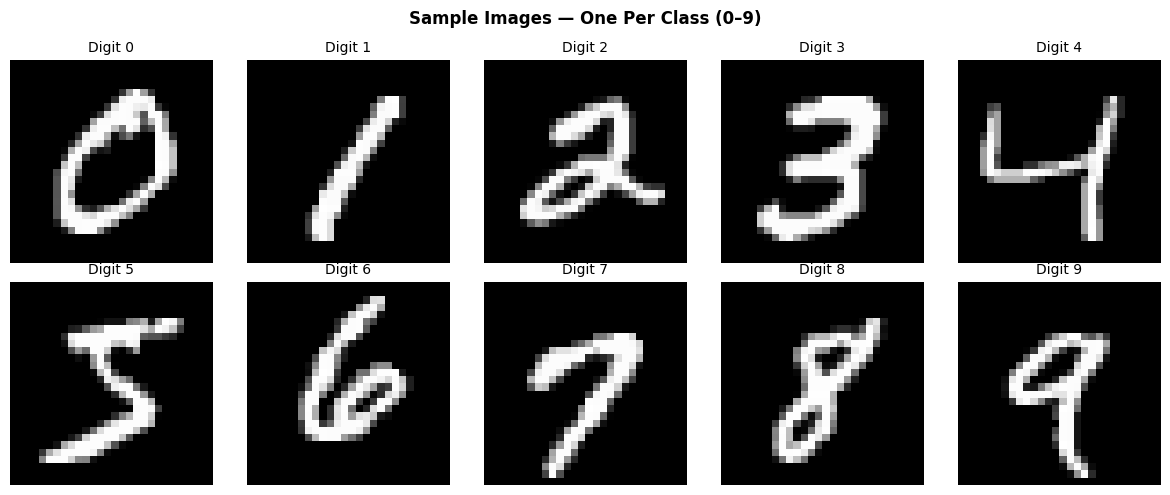

Saved → mnist_samples.png


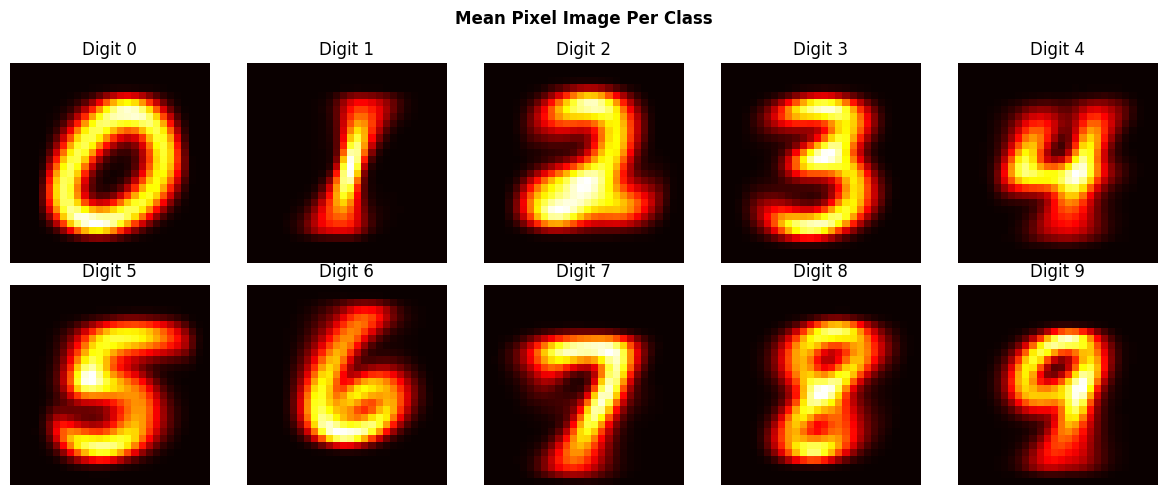

Saved → mnist_mean_images.png
MultiClassMLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=512, out_features=256, bias=True)
    (6): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=256, out_features=128, bias=True)
    (10): ReLU()
    (11): Linear(in_features=128, out_features=10, bias=True)
  )
)
Epoch [1/2]  Loss: 0.3618  Acc: 0.8878
Epoch [2/2]  Loss: 0.2079  Acc: 0.9340

Model weights saved → mnist_model.pth

── Classification Report ──
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.9

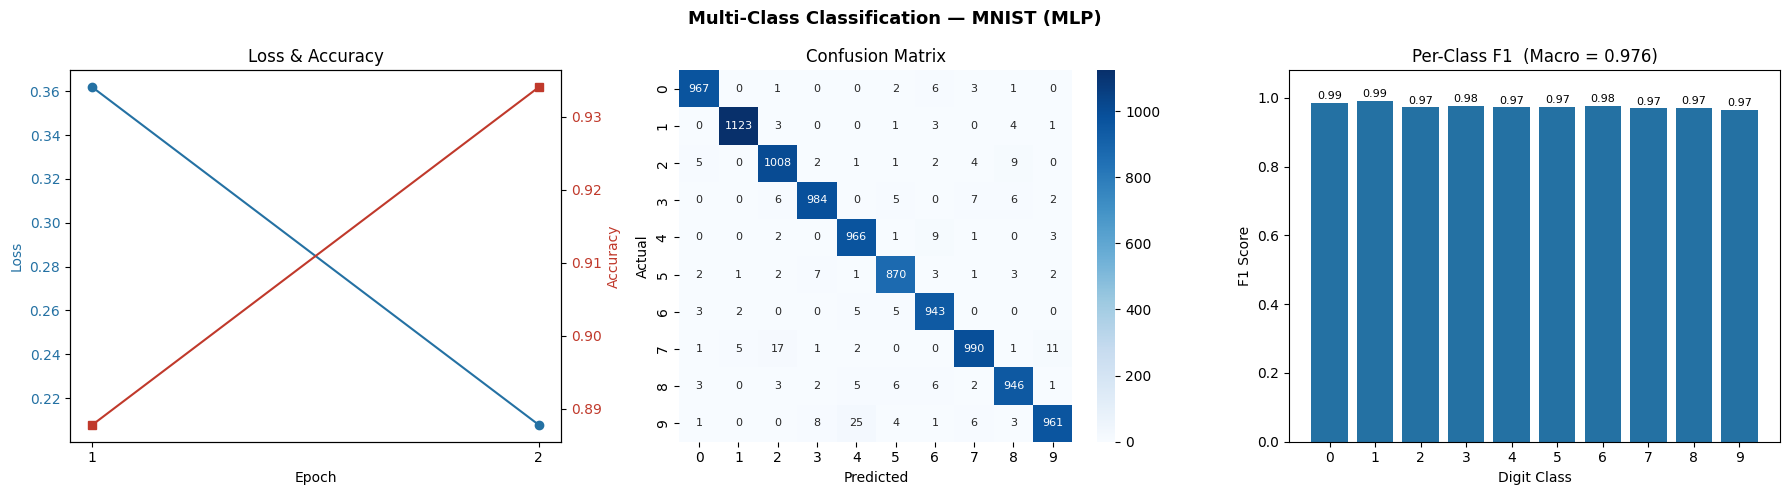

Saved → mnist_results.png


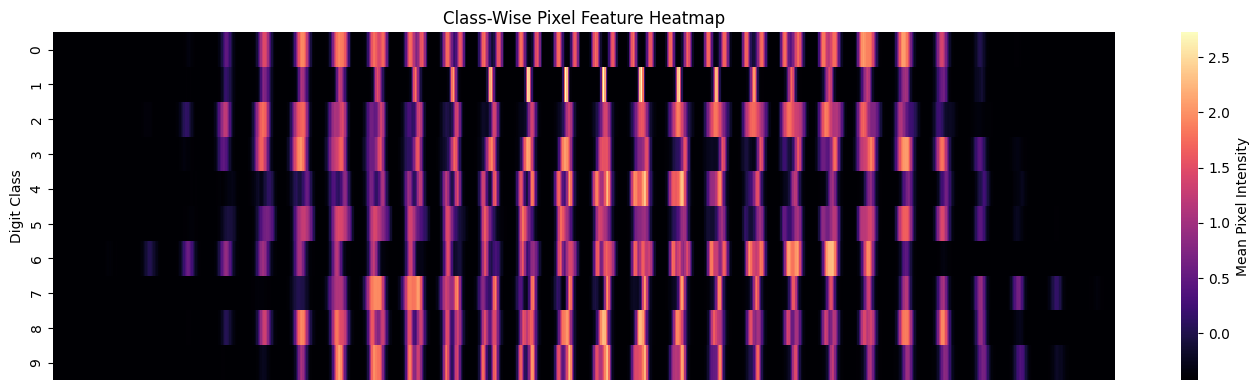

Saved → mnist_pixel_heatmap.png


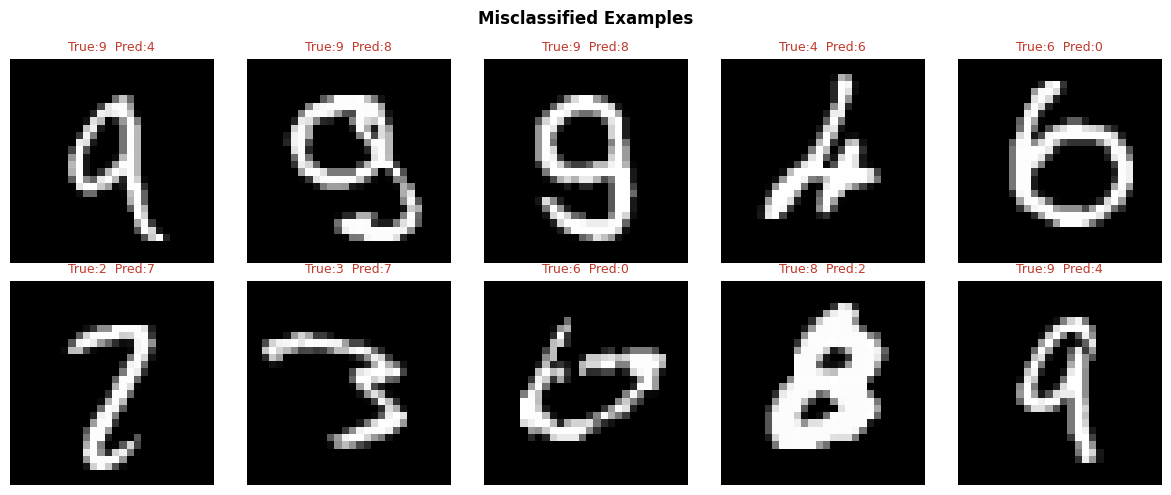

Saved → mnist_misclassified.png


In [5]:
# ============================================================
#  MULTI-CLASS CLASSIFICATION — MNIST (digits 0–9)
#  Model   : MLP
#  UI      : Gradio with IMAGE UPLOAD (no sketchpad)
#            HuggingFace Spaces ready — no API keys required
#
#  HOW TO RUN
#  ----------
#  Step 1 → Run BLOCK 1 to train and save mnist_model.pth
#  Step 2 → Run BLOCK 2 to launch the Gradio upload UI
#
#  pip install torch torchvision gradio scikit-learn matplotlib seaborn
# ============================================================


# ╔══════════════════════════════════════════════════════════════╗
# ║  —> TRAINING & SAVING MODEL WEIGHTS                          ║
# ╚══════════════════════════════════════════════════════════════╝

# ── Imports ──────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score
)
from sklearn.preprocessing import label_binarize

# ── Config ───────────────────────────────────────────────────
NUM_CLASSES   = 10
EPOCHS        = 2           # ← change epochs
BATCH_SIZE    = 64          # ← change batch size
LEARNING_RATE = 1e-3        # ← change learning rate
MODEL_PATH    = "mnist_model.pth"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ── Image Transforms ─────────────────────────────────────────
# Training: augmentation to improve generalisation
train_transform = transforms.Compose([
    transforms.RandomRotation(10),          # ← change degrees or remove to disable
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # ← MNIST mean/std
])

# Test: no augmentation — only normalise
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# ── Load MNIST ───────────────────────────────────────────────
train_set = datasets.MNIST(root="./data", train=True,  download=True, transform=train_transform)
test_set  = datasets.MNIST(root="./data", train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f"Train: {len(train_set)} images | Test: {len(test_set)} images")

# ── Image EDA — Sample images per class ──────────────────────
raw_set   = datasets.MNIST(root="./data", train=True, download=False,
                            transform=transforms.ToTensor())
class_imgs = {}
for img, lbl in raw_set:
    if lbl not in class_imgs:
        class_imgs[lbl] = img.squeeze().numpy()
    if len(class_imgs) == 10:
        break

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Sample Images — One Per Class (0–9)", fontsize=12, fontweight="bold")
for i in range(10):
    ax = axes[i // 5, i % 5]
    ax.imshow(class_imgs[i], cmap="gray")
    ax.set_title(f"Digit {i}", fontsize=10); ax.axis("off")
plt.tight_layout()
plt.savefig("mnist_samples.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → mnist_samples.png")

# ── Image EDA — Mean image per class ─────────────────────────
mean_imgs = {c: [] for c in range(10)}
for imgs, lbls in DataLoader(raw_set, batch_size=1024, shuffle=False):
    for c in range(10):
        mask = lbls == c
        if mask.any():
            mean_imgs[c].append(imgs[mask].squeeze(1).numpy())

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Mean Pixel Image Per Class", fontsize=12, fontweight="bold")
for c in range(10):
    avg = np.concatenate(mean_imgs[c]).mean(axis=0)
    ax  = axes[c // 5, c % 5]
    ax.imshow(avg, cmap="hot"); ax.set_title(f"Digit {c}"); ax.axis("off")
plt.tight_layout()
plt.savefig("mnist_mean_images.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → mnist_mean_images.png")

# ── Model Definition ─────────────────────────────────────────
class MultiClassMLP(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),               # 1×28×28 → 784

            # ── LAYER 1 ──────────────────────────────────────
            nn.Linear(784, 512),        # ← change units: 256, 1024
            nn.BatchNorm1d(512),        # ← remove to disable BatchNorm
            nn.ReLU(),                  # ← swap: nn.Tanh() | nn.GELU() | nn.LeakyReLU(0.1)
            nn.Dropout(0.3),            # ← change dropout rate

            # ── LAYER 2 ──────────────────────────────────────
            nn.Linear(512, 256),        # ← change units
            nn.BatchNorm1d(256),        # ← remove to disable BatchNorm
            nn.ReLU(),                  # ← swap activation
            nn.Dropout(0.3),            # ← change dropout rate

            # ── LAYER 3 ──────────────────────────────────────
            nn.Linear(256, 128),        # ← change units
            nn.ReLU(),                  # ← swap activation

            # ── ADD MORE LAYERS HERE ─────────────────────────
            # nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.2),

            # ── OUTPUT ───────────────────────────────────────
            nn.Linear(128, num_classes) # no Softmax — CrossEntropyLoss includes it
        )

    def forward(self, x):
        return self.net(x)

model = MultiClassMLP(NUM_CLASSES).to(DEVICE)
print(model)

# ── Loss & Optimizer ─────────────────────────────────────────
criterion = nn.CrossEntropyLoss()                               # ← standard multi-class loss
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)   # ← swap: optim.SGD(momentum=0.9)
# scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)  # ← uncomment to use

# ── Training Loop ────────────────────────────────────────────
train_losses, train_accs = [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        correct      += (out.argmax(1) == lbls).sum().item()
        total        += lbls.size(0)

    train_losses.append(running_loss / total)
    train_accs.append(correct / total)
    print(f"Epoch [{epoch}/{EPOCHS}]  Loss: {train_losses[-1]:.4f}  Acc: {train_accs[-1]:.4f}")
    # scheduler.step()  # ← uncomment if using LR scheduler

# ── Save Model Weights ───────────────────────────────────────
torch.save({
    "model_state_dict": model.state_dict(),
    "num_classes"     : NUM_CLASSES,
}, MODEL_PATH)
print(f"\nModel weights saved → {MODEL_PATH}")

# ── Evaluation ───────────────────────────────────────────────
model.eval()
all_preds, all_probs, all_labels = [], [], []

with torch.no_grad():
    for imgs, lbls in test_loader:
        logits = model(imgs.to(DEVICE))
        probs  = torch.softmax(logits, 1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(lbls.numpy())

all_labels = np.array(all_labels)
all_preds  = np.array(all_preds)
all_probs  = np.array(all_probs)
CLASS_NAMES = [str(i) for i in range(10)]

print("\n── Classification Report ──")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

f1_mac  = f1_score(all_labels, all_preds, average="macro")
lbl_bin = label_binarize(all_labels, classes=list(range(10)))
auc_mac = roc_auc_score(lbl_bin, all_probs, multi_class="ovr", average="macro")
print(f"Macro F1 : {f1_mac:.4f}")
print(f"Macro AUC: {auc_mac:.4f}")

# ── Results Plots ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Multi-Class Classification — MNIST (MLP)", fontsize=13, fontweight="bold")
c1, c2 = "#2471A3", "#C0392B"

ax1 = axes[0]
ax1.plot(range(1, EPOCHS+1), train_losses, marker="o", color=c1)
ax1.set_ylabel("Loss", color=c1); ax1.set_xlabel("Epoch")
ax1.tick_params(axis="y", labelcolor=c1); ax1.set_xticks(range(1, EPOCHS+1))
ax1r = ax1.twinx()
ax1r.plot(range(1, EPOCHS+1), train_accs, marker="s", color=c2)
ax1r.set_ylabel("Accuracy", color=c2); ax1r.tick_params(axis="y", labelcolor=c2)
ax1.set_title("Loss & Accuracy")

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            annot_kws={"size": 8})
axes[1].set_title("Confusion Matrix")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

f1_per = f1_score(all_labels, all_preds, average=None)
axes[2].bar(CLASS_NAMES, f1_per, color=c1)
axes[2].set_ylim(0, 1.08)
axes[2].set_xlabel("Digit Class"); axes[2].set_ylabel("F1 Score")
axes[2].set_title(f"Per-Class F1  (Macro = {f1_mac:.3f})")
for i, v in enumerate(f1_per):
    axes[2].text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("mnist_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → mnist_results.png")

# ── Feature Heatmap — mean pixel per class ────────────────────
mean_px = np.zeros((10, 784)); counts = np.zeros(10)
for imgs, lbls in DataLoader(test_set, batch_size=512, shuffle=False):
    flat = imgs.view(imgs.size(0), -1).numpy()
    for c in range(10):
        mask = lbls.numpy() == c
        mean_px[c] += flat[mask].sum(0)
        counts[c]  += mask.sum()
mean_px /= counts[:, None]

fig2, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(mean_px, cmap="magma", ax=ax, yticklabels=CLASS_NAMES,
            xticklabels=False, cbar_kws={"label": "Mean Pixel Intensity"})
ax.set_ylabel("Digit Class")
ax.set_title("Class-Wise Pixel Feature Heatmap")
plt.tight_layout()
plt.savefig("mnist_pixel_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → mnist_pixel_heatmap.png")

# ── Misclassified Examples ────────────────────────────────────
errors = []
model.eval()
with torch.no_grad():
    for img, lbl in DataLoader(test_set, batch_size=1, shuffle=False):
        if len(errors) >= 10:
            break
        pred = model(img.to(DEVICE)).argmax(1).item()
        if pred != lbl.item():
            errors.append((img.squeeze().numpy(), lbl.item(), pred))

fig3, axes3 = plt.subplots(2, 5, figsize=(12, 5))
fig3.suptitle("Misclassified Examples", fontsize=12, fontweight="bold")
for i, (im, true, pred) in enumerate(errors[:10]):
    ax = axes3[i // 5, i % 5]
    ax.imshow(im, cmap="gray")
    ax.set_title(f"True:{true}  Pred:{pred}", fontsize=9, color=c2)
    ax.axis("off")
plt.tight_layout()
plt.savefig("mnist_misclassified.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → mnist_misclassified.png")


In [6]:


# ╔══════════════════════════════════════════════════════════════╗
# ║  —> LOAD WEIGHTS & LAUNCH GRADIO UI                          ║
# ║  Upload a digit image → model predicts 0–9                   ║
# ║  HuggingFace Spaces compatible — no sketchpad, upload only   ║
# ╚══════════════════════════════════════════════════════════════╝

import gradio as gr
import torch
import torch.nn as nn
import numpy as np
from torchvision import transforms
from PIL import Image, ImageOps

MODEL_PATH = "mnist_model.pth"

# ── Recreate architecture (must match Block 1) ────────────────
class MultiClassMLP(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.net(x)

# ── Load saved weights ────────────────────────────────────────
ckpt  = torch.load(MODEL_PATH, map_location="cpu")
model = MultiClassMLP(ckpt["num_classes"])
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"Model loaded from {MODEL_PATH}")

# ── Inference transform — same as test, no augmentation ───────
infer_transform = transforms.Compose([
    transforms.Grayscale(),             # ensure single channel
    transforms.Resize((28, 28)),        # resize to MNIST input size
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # same MNIST normalisation
])

# ── Inference function ────────────────────────────────────────
def predict_digit(uploaded_image):
    """
    Accepts a PIL image uploaded by the user.
    Preprocesses it to match MNIST format (white digit, black background).
    Returns a dict of {digit_label: probability} for Gradio Label widget.
    """
    if uploaded_image is None:
        return {str(i): 0.0 for i in range(10)}

    img = Image.fromarray(uploaded_image).convert("L")  # convert to grayscale

    # Auto-invert if background appears white (uploaded image is likely dark digit on white)
    # MNIST format: white digit on BLACK background
    pixel_mean = np.array(img).mean()
    if pixel_mean > 127:
        img = ImageOps.invert(img)  # invert so digit is white on black

    # Apply inference transforms
    x = infer_transform(img).unsqueeze(0)   # shape: (1, 1, 28, 28)

    with torch.no_grad():
        probs = torch.softmax(model(x), dim=1).squeeze().numpy()

    # Return as label-probability dict for Gradio Label widget
    return {str(i): float(probs[i]) for i in range(10)}

# ── Gradio Interface ──────────────────────────────────────────
with gr.Blocks(title="MNIST Digit Classifier — Upload") as demo:
    gr.Markdown(
        "## 🔢 MNIST Digit Classifier\n"
        "Upload a **28×28 grayscale image** of a handwritten digit (0–9).\n\n"
        "The model will predict which digit it is and show confidence for each class."
    )

    with gr.Row():
        with gr.Column(scale=1):
            image_input = gr.Image(
                label="Upload Digit Image",
                type="numpy",           # returns numpy array to predict_digit
                image_mode="L",         # grayscale
                height=280,
            )
            btn = gr.Button("Classify", variant="primary")

        with gr.Column(scale=1):
            output = gr.Label(
                num_top_classes=10,     # show all 10 digit probabilities
                label="Prediction Probabilities"
            )

    btn.click(fn=predict_digit, inputs=image_input, outputs=output)

    # Auto-predict on upload without needing to click the button
    image_input.change(fn=predict_digit, inputs=image_input, outputs=output)

    gr.Markdown(
        "---\n"
        "- Works best with clean, single digits (no borders or noise)\n\n"
        "> Model: MLP trained on MNIST (60,000 images, 2 epochs)"
    )

# share=False → local only (HuggingFace Spaces handles the public URL automatically)
# share=True  → generates a public link when running locally
demo.launch(share=False)

Model loaded from mnist_model.pth
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>